# Module 5 Homework Notebook — NOAA Buoy (Station 44013)  
**Tree methods + margins/kernels + model selection (D–E)**

In this notebook you’ll apply Module 5 Sections **D–E** to the NOAA buoy dataset (station **44013**):

- **D (Tree-based methods):**
  - Decision Trees
  - Random Forests
  - Gradient Boosting
- **E (Margins, kernels, and model selection):**
  - Linear SVM
  - RBF SVM
  - Comparing model families under one evaluation protocol

This notebook is the second NOAA practice notebook and is designed to follow **HW-5-1**, which focused on Sections **A–C**.

---

## What you’ll practice
You will work on two tasks:

### Regression
Predict **significant wave height** (`WVHT`)

### Classification
Predict **wind_high** (high-wind event flag)

Then you will compare model families and answer a professional ML question:

> Which model would I actually deploy, and why?

---

## Important framing
This notebook is not about chasing the highest score.

It is about learning to compare:
- flexibility
- stability
- interpretability
- computational cost
- calibration
- slice robustness


In [2]:
# === Setup ===


## 1) Load curated NOAA data (same artifact path as HW-5-1)

This notebook uses the parquet file produced in the NOAA Module 2 homework:

- `~/work/homework_2_noaa/data/warehouse/ndbc_curated_44013.parquet`

We keep the same loading style as HW-5-1 so the workflow stays familiar.


In [3]:
# Paths from Module 2 NOAA homework


Looking for: /home/jupyter-kerblesl@isu.edu/work/homework_2_noaa/data/warehouse/ndbc_curated_44013.parquet
Exists? True
Loaded source: hw2_noaa_curated_parquet
Shape: (6470, 18)


,station_id,time_utc,obs_day,obs_hour,dayofweek,is_weekend,wind_high,temp_gap_c,WSPD,GST,WVHT,DPD,APD,PRES,ATMP,WTMP,WDIR,_source
0,44013,2026-01-25 05:40:00+00:00,2026-01-25,5,6,1,0,-15.3,9.0,12.0,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0,hw2_noaa_curated_parquet
1,44013,2026-01-25 05:30:00+00:00,2026-01-25,5,6,1,0,-15.3,10.0,12.0,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0,hw2_noaa_curated_parquet
2,44013,2026-01-25 05:20:00+00:00,2026-01-25,5,6,1,0,-15.1,9.0,12.0,1.2,5.0,3.8,1037.2,-10.2,4.9,330.0,hw2_noaa_curated_parquet
3,44013,2026-01-25 05:10:00+00:00,2026-01-25,5,6,1,0,-15.0,9.0,12.0,NaN,NaN,NaN,1037.4,-10.1,4.9,330.0,hw2_noaa_curated_parquet
4,44013,2026-01-25 05:00:00+00:00,2026-01-25,5,6,1,0,-15.0,9.0,12.0,NaN,NaN,NaN,1037.4,-10.2,4.8,320.0,hw2_noaa_curated_parquet


## 2) Quick schema + missingness snapshot

Before modeling, confirm:
- column types
- missing-value patterns
- target balance for classification


station_id                 object
time_utc      datetime64[ns, UTC]
obs_day                    object
obs_hour                    int32
dayofweek                   int32
is_weekend                  int64
wind_high                   int64
temp_gap_c                float64
WSPD                      float64
GST                       float64
WVHT                      float64
DPD                       float64
APD                       float64
PRES                      float64
ATMP                      float64
WTMP                      float64
WDIR                      float64
_source                    object
dtype: object


,% missing
DPD,67.22
WVHT,59.80
APD,59.80
temp_gap_c,1.30
WTMP,1.21
WDIR,0.34
ATMP,0.15
WSPD,0.09
GST,0.09
PRES,0.05


time_utc min: 2025-12-11 00:00:00+00:00
time_utc max: 2026-01-25 05:40:00+00:00
wind_high rate: 0.16367851622874807
WVHT mean: 0.9838523644752019


## 3) Preprocessing helper (same style as HW-5-1 / Module 5.B–E)

We keep the exact same preprocessing pattern as your earlier notebooks:
- numeric / bool → median impute + standardize
- categoricals → most frequent impute + one-hot encode
- datetimes → dropped by default

This avoids the NaN and dtype issues you’ve seen before.


## 4) Shared split helper (same protocol as HW-5-1)

We use a random split:
- train: 70%
- validation: 15%
- test: 15%

For classification we stratify by the label.


## 5) Shared metric helpers

We’ll use the same reporting pattern throughout.


# Part D — Tree-based methods (Regression)

We’ll keep the same regression target from HW-5-1:

> **Target:** `WVHT`

We will compare:
- mean predictor
- linear regression baseline
- decision tree regressor
- random forest regressor
- gradient boosting regressor


Regression rows: 2601


,obs_hour,dayofweek,is_weekend,wind_high,temp_gap_c,WSPD,GST,DPD,APD,PRES,ATMP,WTMP,WDIR
2,5,6,1,0,-15.1,9.0,12.0,5.0,3.8,1037.2,-10.2,4.9,330.0
5,4,6,1,0,-15.0,10.0,12.0,4.0,3.8,1037.6,-10.1,4.9,320.0
8,4,6,1,0,-14.9,10.0,13.0,4.0,3.8,1037.6,-10.0,4.9,320.0


In [9]:
# Random split for regression
Xtr_r, Xva_r, Xte_r, ytr_r, yva_r, yte_r = split_random(X_reg, y_reg)

pre_r = build_preprocessor(Xtr_r)
num_r, cat_r, dt_r = describe_cols(Xtr_r)
print("Regression columns:", len(num_r), "numeric |", len(cat_r), "categorical |", len(dt_r), "datetime dropped")


Regression columns: 13 numeric | 0 categorical | 0 datetime dropped


## D.1 Baselines for regression

In [10]:
# Mean predictor


# Linear baseline



,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,fit_seconds
1,linear_regression_test,0.152646,0.217123,0.817806,0.109992,0.306654,0.446774,0.023271
0,mean_predictor_test,0.391583,0.510318,-0.006477,0.372363,0.727637,0.977637,NaN


## D.2 Tree regressors — validation search
Do a validation search across Decision Trees, Random Forests, and Gradient Boosting

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,family,fit_seconds,max_depth,n_estimators,learning_rate
13,gbr_lr0.08_n250_val,0.082914,0.126739,0.944060,0.058265,0.170292,0.231636,GradientBoostingRegressor,0.672194,NaN,250.0,0.08
12,gbr_lr0.08_n120_val,0.090351,0.135248,0.936296,0.068136,0.180391,0.255437,GradientBoostingRegressor,0.315734,NaN,120.0,0.08
11,gbr_lr0.03_n250_val,0.092961,0.139474,0.932253,0.066466,0.183868,0.265422,GradientBoostingRegressor,0.657271,NaN,250.0,0.03
9,rfr_n300_d12_val,0.091317,0.144872,0.926908,0.066371,0.178676,0.261384,RandomForestRegressor,1.666693,12.0,300.0,NaN
7,rfr_n300_dNone_val,0.091301,0.144880,0.926899,0.066197,0.178677,0.261384,RandomForestRegressor,1.749381,NaN,300.0,NaN
4,rfr_n150_dNone_val,0.091460,0.145203,0.926573,0.064673,0.184388,0.259325,RandomForestRegressor,0.788025,NaN,150.0,NaN
6,rfr_n150_d12_val,0.091466,0.145305,0.926470,0.064681,0.184386,0.259325,RandomForestRegressor,0.866055,12.0,150.0,NaN
5,rfr_n150_d8_val,0.094939,0.147596,0.924133,0.066349,0.184017,0.255058,RandomForestRegressor,0.792684,8.0,150.0,NaN
8,rfr_n300_d8_val,0.095340,0.147900,0.923820,0.069010,0.180767,0.258694,RandomForestRegressor,1.596081,8.0,300.0,NaN
10,gbr_lr0.03_n120_val,0.109602,0.158940,0.912023,0.081531,0.223274,0.322172,GradientBoostingRegressor,0.334761,NaN,120.0,0.03


Best tree regressor on validation:


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,family,fit_seconds,max_depth,n_estimators,learning_rate
13,gbr_lr0.08_n250_val,0.082914,0.126739,0.94406,0.058265,0.170292,0.231636,GradientBoostingRegressor,0.672194,NaN,250.0,0.08


Test results:


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,fit_seconds
2,gbr_lr0.08_n250_test,0.072014,0.096804,0.963784,0.057746,0.153720,0.199491,0.672194
1,linear_regression_test,0.152646,0.217123,0.817806,0.109992,0.306654,0.446774,0.023271
0,mean_predictor_test,0.391583,0.510318,-0.006477,0.372363,0.727637,0.977637,NaN


## D.3 Regression diagnostics: residuals + tail risk
Give your analysis of the results

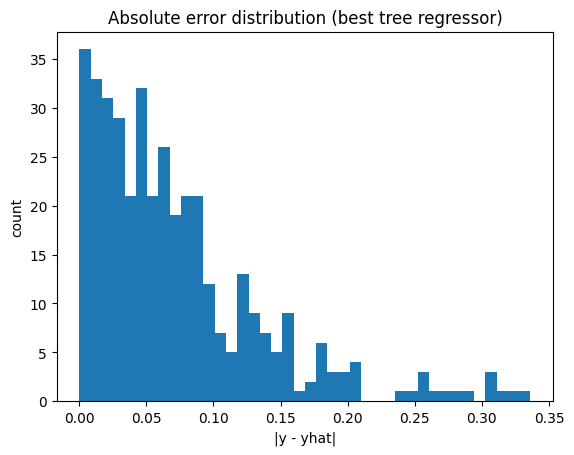

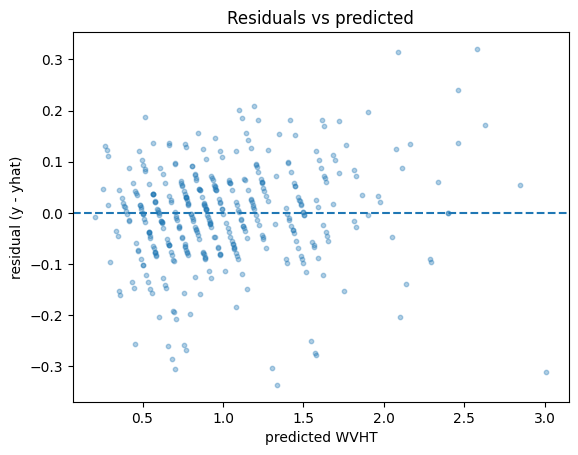

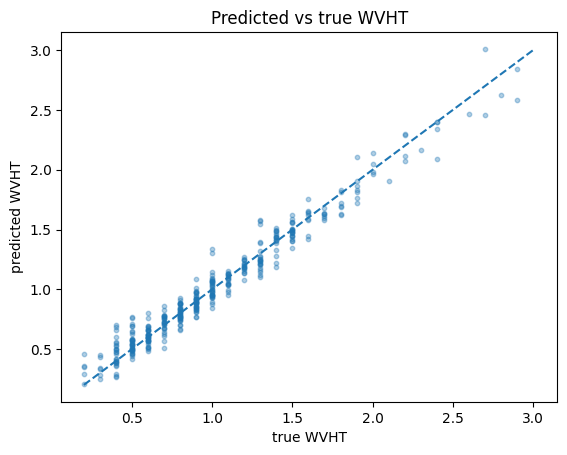

Median abs error: 0.057746226811061285
P90 abs error: 0.15372029023280098
P95 abs error: 0.19949085114895382


#### Your analysis here


## D.4 Slice analysis by wind regime

To see where the regressor struggles, slice the test set by wind direction (`WDIR`) quartiles.


,n,MAE,RMSE,P90AbsErr
WDIR_bin,,,,
"(280.0, 360.0]",97.0,0.089207,0.120697,0.217262
"(260.0, 280.0]",76.0,0.072368,0.093581,0.150334
"(9.999, 220.0]",120.0,0.070235,0.091819,0.155831
"(220.0, 260.0]",97.0,0.057145,0.076832,0.126103


#### Your analysis here


## D.5 Tree regressor feature importance

,feature,importance
8,APD,0.498220
6,GST,0.209429
5,WSPD,0.154670
10,ATMP,0.033219
9,PRES,0.032193
12,WDIR,0.024503
11,WTMP,0.012466
1,dayofweek,0.012104
4,temp_gap_c,0.011834
7,DPD,0.005658


#### Your analysis here


# Part E — Margins, kernels, and model selection (Classification)

We keep the same classification label as HW-5-1:

> **Target:** `wind_high`

But we deliberately drop likely direct revealers:
- `WSPD`
- `GST`

That forces the models to learn from the rest of the buoy context rather than “cheating” with the direct wind measures.


Rows: 6470
Positive rate: 0.16367851622874807


,obs_hour,dayofweek,is_weekend,temp_gap_c,WVHT,DPD,APD,PRES,ATMP,WTMP,WDIR
0,5,6,1,-15.3,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0
1,5,6,1,-15.3,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0
2,5,6,1,-15.1,1.2,5.0,3.8,1037.2,-10.2,4.9,330.0


Classification split sizes: 4528 971 971
Positive rates: 0.16364840989399293 0.16374871266735325 0.16374871266735325
Columns: 11 numeric | 0 categorical | 0 datetime dropped


## E.1 Baselines: majority predictor + logistic regression

,label,threshold,accuracy,precision,recall,f1
0,majority_predictor_test,None,0.836251,0.0,0.0,0.0


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,family,fit_seconds
0,logreg_val,0.5,0.824923,0.48,0.830189,0.608295,0.909665,0.709785,0.123778,0.385903,LogisticRegression,0.024541


## E.2 Tree classifiers on the same task
Do a validation search across Decision Trees, Random Forests, and Gradient Boosting

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,family,fit_seconds,max_depth,n_estimators,learning_rate
11,gbc_lr0.08_n250_val,0.5,0.963955,0.936620,0.836478,0.883721,0.994175,0.971995,0.024383,0.090189,GradientBoostingClassifier,1.755245,NaN,250.0,0.08
6,rfc_n300_dNone_val,0.5,0.958805,0.940741,0.798742,0.863946,0.991596,0.958098,0.031770,0.116647,RandomForestClassifier,1.642796,NaN,300.0,NaN
4,rfc_n150_dNone_val,0.5,0.960865,0.941606,0.811321,0.871622,0.991495,0.957941,0.031800,0.116643,RandomForestClassifier,0.895077,NaN,150.0,NaN
5,rfc_n150_d10_val,0.5,0.955716,0.939394,0.779874,0.852234,0.990434,0.954942,0.034065,0.125212,RandomForestClassifier,0.854517,10.0,150.0,NaN
7,rfc_n300_d10_val,0.5,0.956746,0.946565,0.779874,0.855172,0.990473,0.954620,0.034233,0.125639,RandomForestClassifier,1.612349,10.0,300.0,NaN
10,gbc_lr0.08_n120_val,0.5,0.954686,0.925926,0.786164,0.850340,0.986178,0.943541,0.033895,0.124596,GradientBoostingClassifier,0.831974,NaN,120.0,0.08
9,gbc_lr0.03_n250_val,0.5,0.952626,0.918519,0.779874,0.843537,0.983208,0.934080,0.037073,0.135514,GradientBoostingClassifier,1.469765,NaN,250.0,0.03
3,dtc_depth_12_val,0.5,0.941298,0.807229,0.842767,0.824615,0.975989,0.911979,0.037546,0.250727,DecisionTreeClassifier,0.028818,12.0,NaN,NaN
2,dtc_depth_8_val,0.5,0.942327,0.841060,0.798742,0.819355,0.969607,0.899400,0.042185,0.205644,DecisionTreeClassifier,0.019135,8.0,NaN,NaN
8,gbc_lr0.03_n120_val,0.5,0.940268,0.931624,0.685535,0.789855,0.968530,0.892947,0.048545,0.177418,GradientBoostingClassifier,0.705262,NaN,120.0,0.03


## E.3 SVMs on a reduced dense representation

As in Module 5.E, kernel SVMs are expensive on high-dimensional one-hot encoded data.

So we:
- preprocess
- reduce with `TruncatedSVD` if needed
- fit SVMs on a stratified training subset


SVM train subset: 4528
SVM val subset: 971
Features after preprocessing: 11
Using SVD n_components = 10


In [21]:
# Do a validation search with Linear and RBF SVMs


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,family,fit_seconds,C,n_components,gamma
5,svm_rbf_C3.0_g0.1_val,0.5,0.952626,0.889655,0.811321,0.848684,0.980985,0.935507,0.034139,0.122988,RBFSVM,0.950090,3.0,10,0.1
6,svm_rbf_C3.0_g1.0_val,0.5,0.966014,0.937500,0.849057,0.891089,0.981953,0.930387,0.027007,0.110243,RBFSVM,1.830198,3.0,10,1.0
4,svm_rbf_C1.0_g1.0_val,0.5,0.966014,0.937500,0.849057,0.891089,0.978901,0.924180,0.027258,0.112405,RBFSVM,1.836574,1.0,10,1.0
3,svm_rbf_C1.0_g0.1_val,0.5,0.948507,0.903704,0.767296,0.829932,0.972457,0.916008,0.039789,0.143977,RBFSVM,1.089144,1.0,10,0.1
2,svm_linear_C3.0_val,0.5,0.904222,0.794643,0.559748,0.656827,0.907767,0.711069,0.077083,0.258149,LinearSVM,2.005720,3.0,10,NaN
1,svm_linear_C1.0_val,0.5,0.904222,0.794643,0.559748,0.656827,0.907787,0.710896,0.077090,0.258208,LinearSVM,1.365747,1.0,10,NaN
0,svm_linear_C0.3_val,0.5,0.904222,0.794643,0.559748,0.656827,0.907814,0.708917,0.077140,0.258524,LinearSVM,1.876709,0.3,10,NaN


## E.4 Validation leaderboard across model families

,label,family,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,fit_seconds
1,gbc_lr0.08_n250_val,GradientBoostingClassifier,0.963955,0.936620,0.836478,0.883721,0.994175,0.971995,0.024383,1.755245
2,rfc_n300_dNone_val,RandomForestClassifier,0.958805,0.940741,0.798742,0.863946,0.991596,0.958098,0.031770,1.642796
3,rfc_n150_dNone_val,RandomForestClassifier,0.960865,0.941606,0.811321,0.871622,0.991495,0.957941,0.031800,0.895077
4,rfc_n150_d10_val,RandomForestClassifier,0.955716,0.939394,0.779874,0.852234,0.990434,0.954942,0.034065,0.854517
5,rfc_n300_d10_val,RandomForestClassifier,0.956746,0.946565,0.779874,0.855172,0.990473,0.954620,0.034233,1.612349
6,gbc_lr0.08_n120_val,GradientBoostingClassifier,0.954686,0.925926,0.786164,0.850340,0.986178,0.943541,0.033895,0.831974
13,svm_rbf_C3.0_g0.1_val,RBFSVM,0.952626,0.889655,0.811321,0.848684,0.980985,0.935507,0.034139,0.950090
7,gbc_lr0.03_n250_val,GradientBoostingClassifier,0.952626,0.918519,0.779874,0.843537,0.983208,0.934080,0.037073,1.469765
14,svm_rbf_C3.0_g1.0_val,RBFSVM,0.966014,0.937500,0.849057,0.891089,0.981953,0.930387,0.027007,1.830198
15,svm_rbf_C1.0_g1.0_val,RBFSVM,0.966014,0.937500,0.849057,0.891089,0.978901,0.924180,0.027258,1.836574


## E.5 Finalists on test

Take one finalist from each family:
- Logistic Regression
- best tree classifier
- best Linear SVM
- best RBF SVM

Then choose threshold by best validation F1 and compare on the test set.


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,FP_per_1000,FN_per_1000
1,BestTree_test,0.300,0.968074,0.885542,0.924528,0.904615,0.991612,0.958837,0.026462,0.094813,19.567456,12.358393
3,RBFSVM_test,0.400,0.958805,0.904762,0.836478,0.869281,0.983688,0.927337,0.033141,0.122075,14.418126,26.776519
0,LogisticRegression_test,0.775,0.900103,0.718310,0.641509,0.677741,0.913282,0.726599,0.125604,0.383658,41.194645,58.702369
2,LinearSVM_test,0.450,0.899073,0.752066,0.572327,0.650000,0.912612,0.725374,0.077081,0.253592,30.895984,70.030896


#### Your analysis here

## E.6 ROC, PR, and calibration

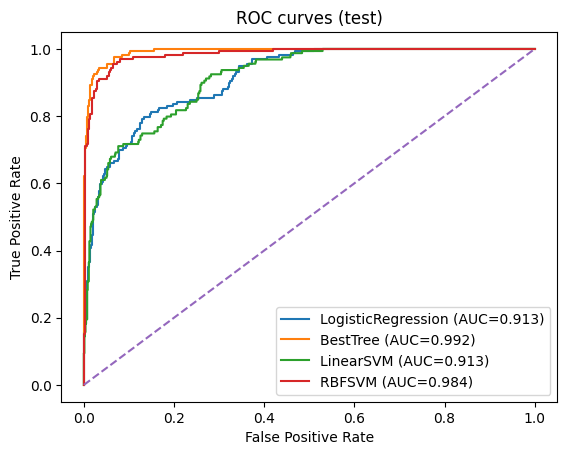

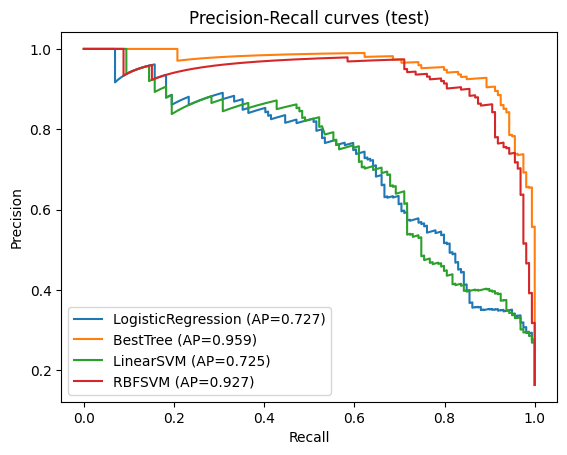

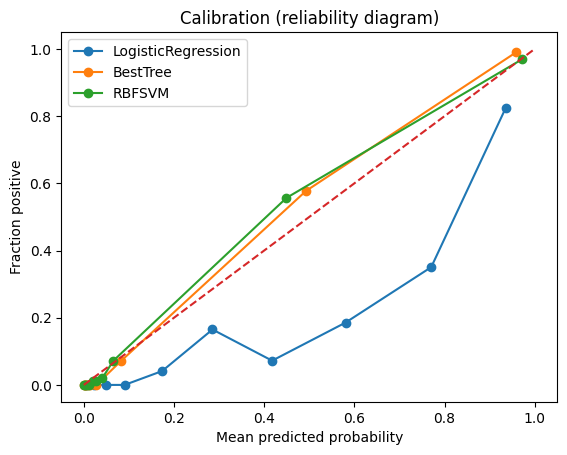

,model,brier,log_loss
1,BestTree,0.026462,0.094813
3,RBFSVM,0.033141,0.122075
2,LinearSVM,0.077081,0.253592
0,LogisticRegression,0.125604,0.383658


#### Your analysis here

## E.7 Support vectors + tree importance

,model,n_support_vectors,train_subset_size,support_vector_fraction
0,LinearSVM,1220,4528,0.269435
1,RBFSVM,775,4528,0.171157


,feature,importance
7,PRES,0.220177
9,WTMP,0.211304
10,WDIR,0.145918
4,WVHT,0.132828
3,temp_gap_c,0.125968
8,ATMP,0.069100
6,APD,0.034621
0,obs_hour,0.031209
1,dayofweek,0.027194
2,is_weekend,0.000860


#### Your analysis here

## E.8 Slice analysis for the deployment candidate

Which model would you actually deploy? Inspect its weakest slices by:
- hour of day (`obs_hour`)
- weekend vs weekday


In [26]:
def slice_report(df_base, y_true, p, threshold, group_col):
    temp = df_base.copy()
    temp["y"] = y_true
    temp["p"] = p
    temp["yhat"] = (temp["p"] >= threshold).astype(int)

    def agg(g):
        y = g["y"].to_numpy()
        yhat = g["yhat"].to_numpy()
        p = g["p"].to_numpy()
        out = {
            "n": len(g),
            "precision": float(precision_score(y, yhat, zero_division=0)),
            "recall": float(recall_score(y, yhat, zero_division=0)),
            "f1": float(f1_score(y, yhat, zero_division=0)),
        }
        try:
            out["roc_auc"] = float(roc_auc_score(y, p))
        except Exception:
            out["roc_auc"] = float("nan")
        return pd.Series(out)

    return temp.groupby(group_col).apply(agg).sort_values("f1")

deploy_name = test_table.iloc[0]["label"].replace("_test", "")
deploy_threshold = chosen_thresholds[deploy_name]
deploy_probs = test_probs[deploy_name]

df_test_base = dfc.loc[Xte_c.index].copy()

if "obs_hour" in df_test_base.columns:
    hour_slice = slice_report(df_test_base, yte_c, deploy_probs, deploy_threshold, group_col="obs_hour")
    display(hour_slice)

if "is_weekend" in df_test_base.columns:
    weekend_slice = slice_report(df_test_base, yte_c, deploy_probs, deploy_threshold, group_col="is_weekend")
    display(weekend_slice)


,n,precision,recall,f1,roc_auc
obs_hour,,,,,
20,44.0,0.555556,1.000000,0.714286,0.989744
11,43.0,0.625000,1.000000,0.769231,0.984211
16,44.0,0.714286,0.833333,0.769231,0.991228
12,37.0,0.777778,0.875000,0.823529,0.974138
8,32.0,1.000000,0.750000,0.857143,1.000000
17,34.0,1.000000,0.750000,0.857143,1.000000
14,36.0,0.750000,1.000000,0.857143,1.000000
7,37.0,0.875000,0.875000,0.875000,0.991379
1,42.0,0.800000,1.000000,0.888889,1.000000


,n,precision,recall,f1,roc_auc
is_weekend,,,,,
1,321.0,0.781250,0.925926,0.847458,0.990930
0,650.0,0.910448,0.924242,0.917293,0.991371


#### Your analysis here

# Deliverable — NOAA D/E model selection memo

Complete the following using your actual outputs.

1. Which tree-based regressor performed best on validation?  
2. How much did it improve over the mean predictor and linear regression?  
3. What did the residual plots suggest about where it struggles?  
4. Which wind-direction slice had the highest regression error?  
5. Which features looked most important in the best tree regressor?  
6. Which tree-based classifier performed best on validation?  
7. What were its test precision / recall / F1 / FP_per_1000 / FN_per_1000?  
8. Which slice looked weakest for the best tree classifier?  
9. Which family won on the model-comparison leaderboard?  
10. Did the AP winner also win under F1?  
11. Which model calibrated best?  
12. What did the support-vector fraction suggest about the SVMs?  
13. If recall mattered more than precision, would you change the model or just the threshold?  
14. Which model would you actually deploy?  
15. What would you monitor in production?  
16. What dataset shift would most likely break your chosen model first?
